In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## 1. Importing (Reading) Dataset and checking null values


In [3]:
data = pd.read_csv('weather_activity.csv')

print(data.shape)
data.head()
data.isnull().sum()

(400, 2)


Weather    0
Go_Out     0
dtype: int64

## 2. Encoding the Categorical Variables

In [4]:
le_weather = LabelEncoder()
le_target = LabelEncoder()

data['Weather'] = le_weather.fit_transform(data['Weather'])
data['Go_Out'] = le_target.fit_transform(data['Go_Out'])

print(data.head())

   Weather  Go_Out
0        0       0
1        1       1
2        0       0
3        0       0
4        1       1


## 3. Assigning Dependent and Independent Variables

In [5]:
x = data[['Weather']]
y = data['Go_Out']

print("Independent Variable:")
print(x.head())

print("\nDependent Variable:")
print(y.head())

Independent Variable:
   Weather
0        0
1        1
2        0
3        0
4        1

Dependent Variable:
0    0
1    1
2    0
3    0
4    1
Name: Go_Out, dtype: int64


## 4. Splitting the Dataset into Training and Testing Dataset

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=5
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(320, 1)

(320,)

(80, 1)

(80,)

## 5. Fitting the Model (Decision Tree Classifier)

In [7]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(x_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## 6. Displaying Decision Tree Rules

In [8]:
print(tree.export_text(
    model,
    feature_names=['Weather']
))

|--- Weather <= 0.50
|   |--- class: 0
|--- Weather >  0.50
|   |--- class: 1



## 7. Predicting the Test Data

In [9]:
y_pred = model.predict(x_test)

print('y_pred:', y_pred)

y_pred: [0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 1 1 0 1 0 0 1 1 1 0 0 0 0 1
 1 1 0 1 1 0]


## 8. Confusion Matrix and Accuracy

Confusion Matrix: [[44  0]
 [ 0 36]]
Accuracy Score :  1.0
Accuracy in Percentage: 100 %


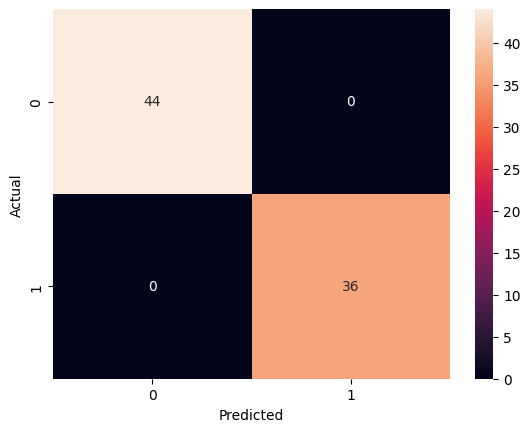

In [10]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print('Confusion Matrix:', conf_mat)

Accuracy_score = metrics.accuracy_score(y_test, y_pred)

print('Accuracy Score : ', Accuracy_score)

print('Accuracy in Percentage:', int(Accuracy_score * 100), '%')

conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)

plt.show()

## 9. Visualizing the Decision Tree

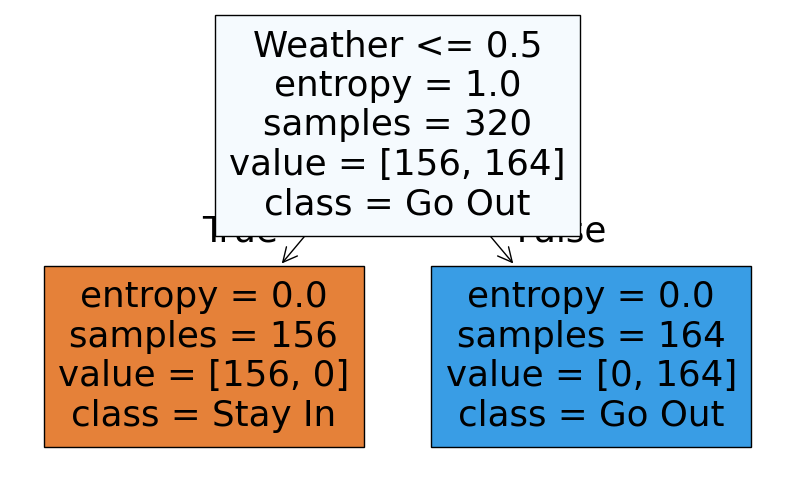

In [11]:
plt.figure(figsize=(10, 6))

tree.plot_tree(
    model,
    feature_names=['Weather'],
    class_names=['Stay In', 'Go Out'],
    filled=True
)

plt.show()

## 10. Predicting a New Weather Condition

In [12]:
sunny = le_weather.transform(['Sunny'])[0]

new_weather = pd.DataFrame(
    [[sunny]],
    columns=['Weather']
)

prediction = model.predict(new_weather)

result = le_target.inverse_transform(prediction)

print("Weather: Sunny")
print("Prediction:", result[0])

Weather: Sunny
Prediction: Yes


## 11. Predicting Rainy Weather

In [13]:
rainy = le_weather.transform(['Rainy'])[0]

new_weather = pd.DataFrame(
    [[rainy]],
    columns=['Weather']
)

prediction = model.predict(new_weather)

result = le_target.inverse_transform(prediction)

print("Weather: Rainy")
print("Prediction:", result[0])

Weather: Rainy
Prediction: No
